In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [86]:
df = pd.read_csv('cw_data.csv', header = None)

In [87]:
classes = np.array(df[1].tolist())
unique, counts = np.unique(classes, return_counts=True)
print(np.asarray((unique, counts)).T)

[['account_recovery' '21']
 ['billing_history' '21']
 ['data_privacy' '22']
 ['delete_account' '23']
 ['login_issue' '16']
 ['notification_settings' '24']
 ['order_tracking' '22']
 ['payment_issue' '33']
 ['refund_request' '21']
 ['reset_password' '20']
 ['shipping_delay' '29']
 ['subscription_management' '23']
 ['two_factor_auth' '10']
 ['update_email' '23']]


###Check for Class Imbalance

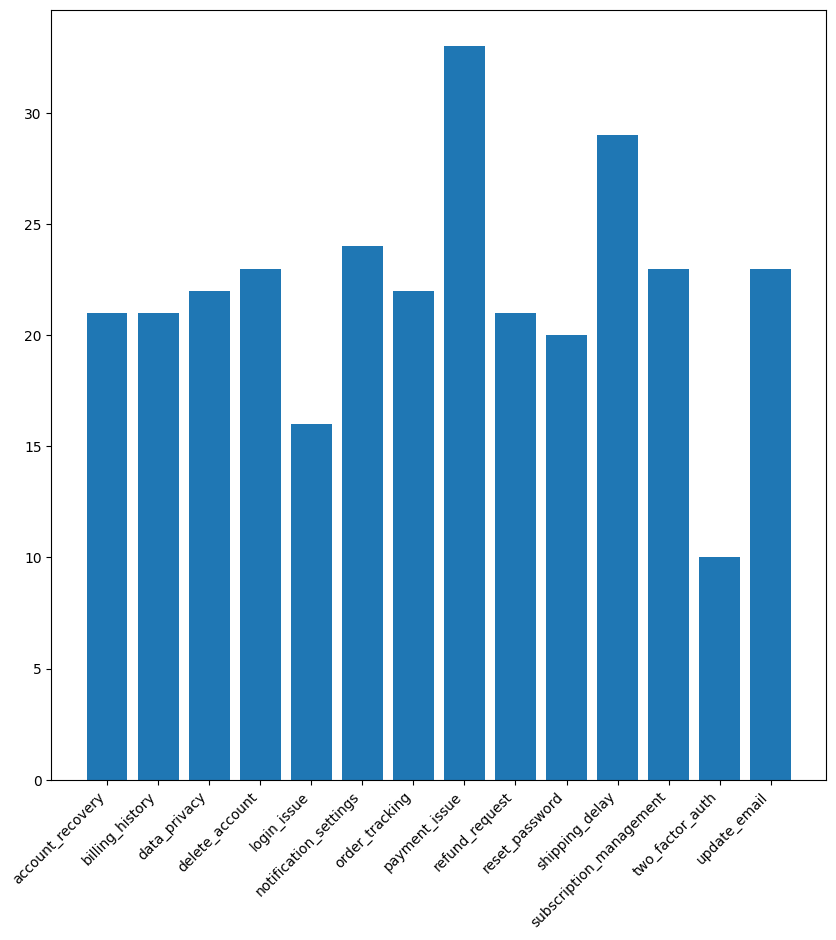

In [88]:
fig, ax = plt.subplots(figsize=(10, 10))

plt.bar(unique, counts, )
plt.xticks(rotation = 45, ha = 'right')
plt.show()

###Remove Capitals

In [89]:
def lowercase(text):
  return text.lower()

###Tokenise

In [90]:
import spacy

In [91]:
nlp = spacy.load("en_core_web_sm")

def tokenise(text):
  processed_doc = nlp(text)
  return processed_doc


###Lemmatise

In [92]:
def lemmatise(document):
  lematised_tokens = [token.lemma_ for token in document]
  return lematised_tokens
print(f"Original:{df[0][1]} | Cleaned: {lemmatise(nlp(df[0][1]))}")

Original:partial shipments tracked separately? | Cleaned: ['partial', 'shipment', 'track', 'separately', '?']


###SpellCheck and hard code

In [93]:
hard_coded_examples = {
    "acct": "account",
    "emial": "email",
    "wat": "what",
    "pls": "please",
    "accts": "accounts",
    "prefs": "preferences",
    "cant" : "not",
    "didnt" : "not",
    "wont" : "not",
    "no"   : "not",
    "1": "one",
    "2": "to"

}


def correct_spelling(document):
  words = document.split()
  cleaned_document = []

  for word in words:
    if word in hard_coded_examples:
      cleaned_document.append(hard_coded_examples[word])
    else:
      cleaned_document.append(word)

  return " ".join(cleaned_document)

print(f"Original: {df[0][3]} | Cleaned: {correct_spelling(df[0][3])}")
print(correct_spelling("didnt"))

Original: recover acct if suspended? | Cleaned: recover account if suspended?
not


###POS Tagging and Filtering

In [94]:
def pos_filter(document, allowed_words=['NOUN', 'VERB', 'ADJ', 'PART']):
  filtered_tokens = [token for token in document if token.pos_ in allowed_words]
  return filtered_tokens
print(f"Original:{df[0][23]} | Cleaned: {pos_filter(nlp(df[0][23]))}")

Original:recovery email not received help pls | Cleaned: [recovery, email, not, received, help]


###Analyse what punctuation is in the dataset

In [95]:
import string

In [96]:
abc = list(string.ascii_lowercase) + list(string.ascii_uppercase)
punc = []
for doc in df[0]:
  for character in doc:
    if character not in abc and character != ' ' and not character.isnumeric():
      punc.append(character)
punc = np.array(punc)
unique, counts = np.unique(punc, return_counts=True)
print(np.asarray((unique, counts)).T)

[['!' '2']
 ['&' '3']
 ["'" '16']
 ['(' '7']
 [')' '7']
 ['-' '7']
 ['.' '8']
 ['/' '8']
 [':' '3']
 [';' '10']
 ['?' '285']
 ['—' '48']
 ['…' '6']
 ['→' '3']]


In [97]:
def check_punctuation(punc):
  query = []
  for i, row in df.iterrows():
    if punc in row[0]:
      query.append(row[1])
  query = np.array(query)
  print(f"There are {query.size} queries with '{punc}'")
  unique, counts = np.unique(query, return_counts=True)
  print(np.asarray((unique, counts)).T)
check_punctuation("(")

There are 7 queries with '('
[['login_issue' '3']
 ['reset_password' '3']
 ['two_factor_auth' '1']]


In [98]:
punc = string.punctuation + "→" + "—" + "…"  + "-"
def remove_punctuation(document):
  translator = str.maketrans('', '', punc)
  clean_text = document.translate(translator)
  return clean_text
print(f"Original:{df[0][4]} | Cleaned: {remove_punctuation(df[0][4])}")

Original:emial update failed error — fix? | Cleaned: emial update failed error  fix


In [99]:
def whitespace_removal(document):
  return document.replace('  ', ' ')



###Put it all together

In [100]:
def preprocess(document):

  x = remove_punctuation(document)
  x = lowercase(x)
  x = correct_spelling(x)
  x = whitespace_removal(x)
  x = nlp(x)
  x = pos_filter(x)
  x = lemmatise(x)

  return x

In [101]:
df2 = df.copy(deep = True)
for i, row in df2.iterrows():
  row[0] = preprocess(row[0])


In [102]:
print(f"{df[0][16]} | {df2[0][16]}")

charge missing in billing history wat 2 do? | ['charge', 'miss', 'billing', 'history', 'to', 'do']


In [103]:
df2.head(3)

,0,1
0,"[tracking, show, ship, not, delivery, help, pl...",shipping_delay
1,"[partial, shipment, track]",order_tracking
2,"[invalid, email, enter, happen]",update_email


###Unigrams

In [104]:
def bag_of_unigrams(documents):
  vocabulary = {}
  dataset = []
  for d in documents:
    for word in d:
      if word not in vocabulary:
        vocabulary[word] = len(vocabulary)

  for d in documents:
    feature_vector = [0] * len(vocabulary)

    for word in d:
      if word in vocabulary:
        feature_vector[vocabulary[word]] += 1
    dataset.append(feature_vector)
  return dataset, vocabulary

In [105]:
unigrams = bag_of_unigrams(df2[0])[0]

###Classification

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV

In [107]:
X_train, X_test, y_train, y_test = train_test_split(unigrams, df2[1], train_size = 0.75, random_state = 32)


Hyperparameter Optimisation

In [108]:
base_model = ComplementNB()

parameters = {
    'alpha': [i*0.01 for i in range(1,101)],
    'norm' : [True, False]
}



In [109]:
grid_search = GridSearchCV(
    estimator = base_model,
    param_grid = parameters,
    cv = 2,
    scoring = 'f1_macro',
    n_jobs = 1
)

In [110]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_


In [111]:
grid_search.best_params_

{'alpha': 0.99, 'norm': False}

In [112]:
predictions = best_model.predict(X_test)

###Evaluation

In [113]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [114]:
classification = classification_report(predictions, y_test.tolist())

In [115]:
print(classification)

                         precision    recall  f1-score   support

       account_recovery       0.67      0.67      0.67         3
        billing_history       1.00      1.00      1.00         7
           data_privacy       1.00      1.00      1.00         6
         delete_account       0.80      1.00      0.89         8
            login_issue       0.75      1.00      0.86         3
  notification_settings       0.67      0.67      0.67         3
         order_tracking       1.00      0.83      0.91         6
          payment_issue       1.00      1.00      1.00        10
         refund_request       1.00      1.00      1.00         1
         reset_password       1.00      0.89      0.94         9
         shipping_delay       0.75      0.86      0.80         7
subscription_management       1.00      0.89      0.94         9
        two_factor_auth       1.00      1.00      1.00         3
           update_email       1.00      0.50      0.67         2

               accuracy

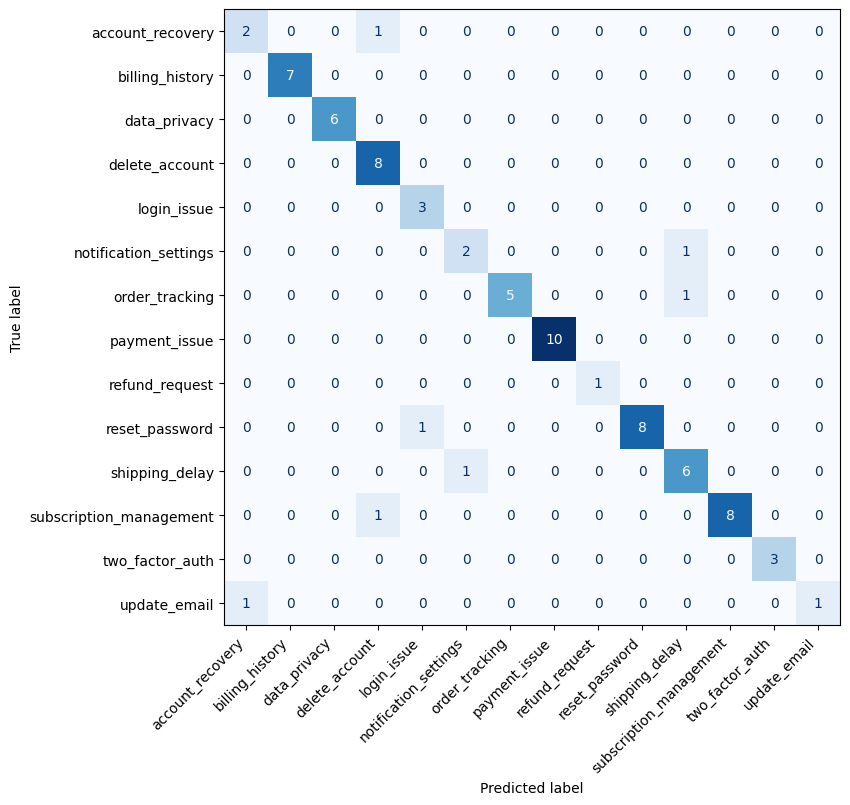

In [116]:
confusion = confusion_matrix(predictions, y_test.tolist(), labels = best_model.classes_)
fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(confusion, display_labels = best_model.classes_)
disp.plot(ax = ax, cmap = 'Blues', colorbar = False)

plt.xticks(rotation = 45, ha = 'right')
plt.show()

###Extra stuff

Look at Example Incorrect Predictions

In [117]:
example_results = pd.DataFrame({'Raw_Text': df.loc[y_test.index, 0],
                                'Processed_Text': df2.loc[y_test.index, 0],
                                'True_Label': y_test,
                                'Predicted_Label': predictions
                                })

In [118]:
example_results[example_results['Predicted_Label'] != example_results['True_Label']]

,Raw_Text,Processed_Text,True_Label,Predicted_Label
258,why courier not updating tracking info?,"[courier, not, update, tracking, info]",shipping_delay,order_tracking
216,shipping notification not received wat 2 do?,"[shipping, notification, not, receive, to, do]",shipping_delay,notification_settings
292,I get a 'credentials incorrect' message even t...,"[get, credential, incorrect, message, password...",login_issue,reset_password
103,recover acct after deletion possible?,"[recover, account, deletion, possible]",delete_account,account_recovery
247,alerts coming multiple times help pls,"[alert, come, multiple, time, help, please]",notification_settings,shipping_delay
174,recover acct after deleting email possible?,"[recover, account, delete, email, possible]",account_recovery,update_email
244,cancel subscription before acct deletion?,"[cancel, subscription, account, deletion]",delete_account,subscription_management


###Check how many times a word occurs in a query
#

In [119]:
def check_word(df, word, query):

  word_total  = 0
  query_total = 0
  both_total  = 0

  search_word = word.lower()

  for i, row in df.iterrows():
    text = str(row[0]).lower()
    label = row[1]

    words = text.split()

    if search_word in words:
      word_total += 1

    if label == query:
      query_total +=1
    if search_word in words and label == query:
      both_total += 1

  if word_total == 0:
    print(f"{word} does not appear in the dataset")
  else:
    print(f"1.{word} occurs {word_total} times")
    print(f"2.When a user types '{word}', it is '{query}' {both_total/word_total*100}% of the time")
  print(f"3.Inside '{query}', the word '{word}' shows up {both_total/query_total*100}% of the time")

In [120]:
check_word(df, "billing", "billing_history")

1.billing occurs 14 times
2.When a user types 'billing', it is 'billing_history' 100.0% of the time
3.Inside 'billing_history', the word 'billing' shows up 66.66666666666666% of the time


In [121]:
check_word(df, "account", "delete_account")
check_word(df, "account", "account_recovery")


1.account occurs 15 times
2.When a user types 'account', it is 'delete_account' 13.333333333333334% of the time
3.Inside 'delete_account', the word 'account' shows up 8.695652173913043% of the time
1.account occurs 15 times
2.When a user types 'account', it is 'account_recovery' 26.666666666666668% of the time
3.Inside 'account_recovery', the word 'account' shows up 19.047619047619047% of the time


In [122]:
check_word(df, "subscription", "subscription_management")

1.subscription occurs 19 times
2.When a user types 'subscription', it is 'subscription_management' 78.94736842105263% of the time
3.Inside 'subscription_management', the word 'subscription' shows up 65.21739130434783% of the time
